Now that I have selected the templates I will find the thresholds.

In [1]:
from pathlib import Path
from calibration_calcs import compute_template_dtw_costs, compute_template_background_dtw_costs, compute_roc_curve, find_threshold_youden_from_roc, compute_auc, plot_roc_curve, plot_dtw_scatter

DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"
RESULTS_29.mkdir(exist_ok=True)

single-tone dtws #10

In [2]:
call_costs, call_pairs = compute_template_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json",
    n_templates=10
)

In [3]:
#print("DTW for template against template:")
#for i in range(len(costs)):
 #   print(i, ":", costs[i])

In [4]:
call_bg_costs, call_bg_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json",
    RESULTS_29 / "20230429_Background_20230429_102841_background.json",
    n_templates=10,
    n_background=5
)

In [5]:
#print("DTW for template against background:")
#for i in range(len(call_bg_costs)):
 #   print(i, ":", call_bg_costs[i])

Threshold: 0.1497 (J = 0.8711)


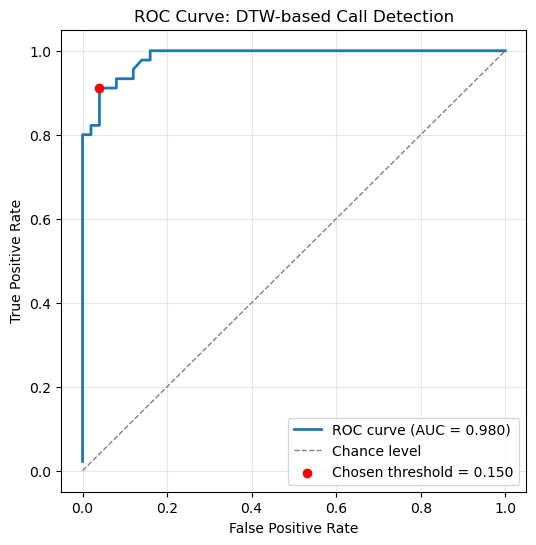

In [8]:
fpr, tpr, thresholds = compute_roc_curve(call_costs, call_bg_costs)
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

print(f"Threshold: {threshold:.4f} (J = {j_stat:.4f})")

auc = compute_auc(fpr, tpr)
plot_roc_curve(call_costs, call_bg_costs, best_threshold=threshold);

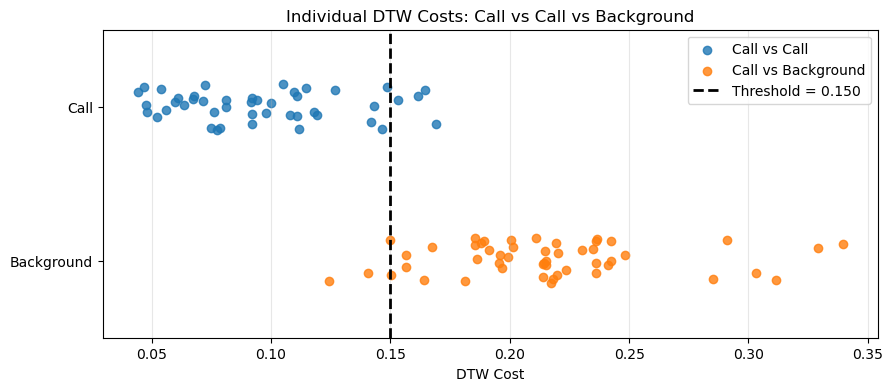

In [7]:
fpr, tpr, thresholds = compute_roc_curve(call_costs, call_bg_costs)
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

plot_dtw_scatter(call_costs, call_bg_costs, threshold=threshold)